In [1]:
import tkinter as tk
from tkinter import filedialog
import pandas as pd
import numpy as np

In [2]:
# data IMPORT MODULE..!
class DataIngestion:
    @staticmethod
    def file_selection():
        root = tk.Tk() 
        root.withdraw()
        root.attributes('-topmost', True)
        file_path = filedialog.askopenfilename(title = "Select a file", initialdir = r'C:\Users\User\Downloads', filetypes = (("Excel files", "*.xlsx"),("CSV files", "*.csv")))
        root.destroy()
        return file_path

    @staticmethod
    def data_reading(filepath): 
        
        if filepath:
            data = None
            try:
                if filepath.endswith(".csv"):
                    data = pd.read_csv(filepath)
                elif filepath.endswith(".xlsx"):
                    data = pd.read_excel(filepath)
                else:
                    print("The file needs to be in .csv or .xlsx format\n")
            except PermissionError:
                print("❌ Permission denied while accessing the file.\n")
            except Exception as e:
                print(f"❌ Unexpected error occurred: {e}\n")
            else:
                print(f"\n\nThe dataset has been successfully uploaded, here's a short preview..!\n\n\n{data.head()}")
                print("\n" + "=" * 110)
        else:
            print("No file selected. Aborting ingestion.\n")
            return None
        return data
    
    @staticmethod
    def memory_downcasting(data):
        Mem = data.copy()
        for col in Mem.select_dtypes(include=['int64']).columns:
            Mem[col] = pd.to_numeric(Mem[col], downcast='integer')
        for col in Mem.select_dtypes(include=['float64']).columns:
            Mem[col] = pd.to_numeric(Mem[col], downcast='float')
        print("\n\nMemory downcasting completed.")
        return Mem


In [3]:
#Summary of data
# Gives a description about data..!
import pandas as pd

def summary_of_data(data):
    columns = data.columns.to_list()
    shape = data.shape
    missing_values = data.isnull().sum()
    duplicates = data.duplicated().sum()

    print(f"The dataset has {shape[0]} rows and {shape[1]} columns.\n")
    print(f"The column names are : {columns}\n")
    print(f"The missing values in each attributes are shown below...!\n\n{missing_values}\n")
    print(F"The dataset has {duplicates} duplicate values.\n")
    print(F"Other things you may want a look into : \n\n{data.describe()}\n")
    print("\n" + "=" * 120)


In [4]:
#column_remover
import pandas as pd

def Remove_col(data):
    try:
        user_input = input("Enter the column names that need to be deleted (example: A,B,C) or 'No':\n")
        
        if user_input.strip().lower() == 'no':
            print("Lets go to the next step..!")
            return data
        else:
            cols = [col.strip() for col in user_input.split(',')]
            data = data.drop(columns=cols)
            print("The mentioned columns got dealt with..!")
            return data 
            
    except KeyError as e:
        print(f"Error: Could not find column {e}. Returning original dataset.")
        return data
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return data

In [ ]:
import pandas as pd
import numpy as np

def dynamic_outlier_clipping(data, skew_threshold=1.0, z_thresh=3.0, iqr_factor=1.5):
    
    df_clipped = data.copy()
    num_cols = df_clipped.select_dtypes(include=[np.number]).columns
    
    print("Starting dynamic outlier clipping...\n")
    
    for col in num_cols:
        skewness = df_clipped[col].skew()
        
        if abs(skewness) > skew_threshold:
            # High skew -> Route to IQR
            q1 = df_clipped[col].quantile(0.25)
            q3 = df_clipped[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - (iqr_factor * iqr)
            upper = q3 + (iqr_factor * iqr)
            strategy = "IQR"
            
        else:
            # Normal distribution -> Route to Z-Score
            mean = df_clipped[col].mean()
            std = df_clipped[col].std()
            lower = mean - (z_thresh * std)
            upper = mean + (z_thresh * std)
            strategy = "Z-Score"
            
        # Apply the bounds
        df_clipped[col] = df_clipped[col].clip(lower=lower, upper=upper)
        print(f" -> [{strategy}] applied to '{col}' (Skewness: {skewness:.2f})")
        
    print("\n" + "=" * 120)
    return df_clipped

In [ ]:
#DUPLICATE REMOVAL..!
import pandas as pd

def remove_duplicates(df):
    initial_count = len(df)
    df = df.drop_duplicates(keep = "first").reset_index(drop=True)
    final_count = len(df)
    print(f"DataForge Removed {initial_count - final_count} duplicate rows.\n")
    print("\n" + "=" * 120)
    return df


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visual_Module(data):
    data_vis = data.select_dtypes(include=[np.number]).copy()
    print("A Histogram of the given dataset is given below..\n")
    data_vis.hist(bins=10, figsize=(10, 10))
    plt.show()
    print("\n" + "=" * 120)
    
    print("A Heatmap of the given dataset is given below..\n")
    corr = data.select_dtypes(include=[np.number]).corr()
    plt.figure(figsize=(8,7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    
    plt.title("Correlation Heatmap")
    plt.show()
    print("\n" + "=" * 120)


In [12]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer, KNNImputer

def multivariate_imputation(data, strategy='knn', n_neighbors=5, max_iter=10):
    
    df_imputed = data.copy()
    
    num_cols = df_imputed.select_dtypes(include=[np.number]).columns
    
    missing_count = df_imputed[num_cols].isnull().sum().sum()
    if missing_count == 0:
        print("No missing values found in numerical columns. Skipping imputation.")
        return df_imputed

    print(f"Starting multivariate imputation using '{strategy.upper()}' strategy...")
    print(f" -> Found {missing_count} missing values to impute.\n")

    if strategy == 'knn':
        imputer = KNNImputer(n_neighbors=n_neighbors)
    elif strategy == 'iterative':
   
        imputer = IterativeImputer(max_iter=max_iter, random_state=42)
    else:
        print(f"❌ Strategy '{strategy}' not recognized. Defaulting to 'knn'.")
        imputer = KNNImputer(n_neighbors=n_neighbors)


    imputed_array = imputer.fit_transform(df_imputed[num_cols])
    df_imputed[num_cols] = pd.DataFrame(imputed_array, columns=num_cols, index=df_imputed.index)
    
    print(" -> Imputation complete.")
    print("\n" + "=" * 55)
    
    return df_imputed

In [ ]:
import pandas as pd

def input_output_separator(df: pd.DataFrame, target_column: str):

    if target_column not in df.columns:
        raise KeyError(f"❌ Target column '{target_column}' not found. Available columns: {df.columns.tolist()}")
        

    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    print(f"✅ Successfully separated features (X) and target (y: '{target_column}')")
    print("-" * 55)
    
    return X, y

In [ ]:
# target_processor.py
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import LabelEncoder

def target_processor(target: pd.Series, task_type="auto"):
    
    target_dtype = target.dtype
    unique_num = target.nunique()
    unique_ratio = unique_num / len(target)

    is_numeric = np.issubdtype(target_dtype, np.number)
    is_categorical = target_dtype == "object" or target_dtype.name == "category" or target_dtype == "bool"


    if task_type == "auto":
        if is_categorical or (is_numeric and unique_num <= 20 and unique_ratio < 0.05):
            task_type = "c"
            print("🧠 Auto-detected task: Classification")
        else:
            task_type = "r"
            print("🧠 Auto-detected task: Regression")
            

    else:
        task_type = task_type.lower()
        if task_type == "r" and not (is_numeric and unique_num > 10 and unique_ratio > 0.1):
            warnings.warn("Target has low cardinality or is categorical. Classification may be more suitable.", UserWarning)
        elif task_type == "c" and not (is_categorical or (is_numeric and unique_num <= 20 and unique_ratio < 0.05)):
            warnings.warn("Target has high cardinality. Regression may be more suitable.", UserWarning)

 
    le = None
    if task_type == "c" and is_categorical:
        le = LabelEncoder()
        # Transform and preserve the original pandas index
        target = pd.Series(le.fit_transform(target), index=target.index)
        print(f"✅ Target column encoded. Classes found: {list(le.classes_)}")
        
    print("-" * 55)
    

    return target, task_type, le

In [ ]:
# regression_model.py
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def reg_model(input_val: pd.DataFrame, target_col: pd.Series):
    df_processed = input_val.copy()
    
    print("Evaluating categorical cardinality...")
    cat_cols = df_processed.select_dtypes(include=['object', 'category']).columns
    
    for col in cat_cols:
        unique_count = df_processed[col].nunique()
        
        if unique_count >= 10:

            freq_map = df_processed[col].value_counts(normalize=True)
            df_processed[col] = df_processed[col].map(freq_map)
            print(f" -> '{col}' ({unique_count} unique) converted via Frequency Encoding.")
            
    
    df_processed = pd.get_dummies(df_processed, drop_first=True, dtype=float)
    
    original_columns = input_val.columns.tolist()
    feature_names = df_processed.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(df_processed, target_col, test_size=0.2, random_state=42)
    
    print("Applying standardization...")
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    

    X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
    }

    best_score = -float('inf')
    best_model = None
    best_name = ""

    print("\nTraining models and evaluating R2 scores...")
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        score = round(r2_score(y_test, pred), 3)
        print(f" -> {name}: {score}")
        
        if score > best_score:
            best_score = score
            best_model = model
            best_name = name

    print(f"\n✅ DataForge automatically selected '{best_name}' for deployment with an R2 of {best_score}.")
    print("-" * 55)
    
    return best_model, best_name, original_columns, feature_names



The dataset has been successfully uploaded, here's a short preview..!


  Student_ID  Gender Employment_Status Device_Type  Course_Level  \
0  STU100000    Male           Student      Laptop  Intermediate   
1  STU100001  Female           Student      Laptop      Advanced   
2  STU100002  Female           Student      Mobile      Beginner   
3  STU100003  Female          Employed      Mobile      Beginner   
4  STU100004  Female     Self-Employed      Laptop      Advanced   

   Login_Frequency  Average_Session_Duration_Min  Video_Completion_Rate  \
0                3                            30                   55.0   
1                4                            37                   84.1   
2                5                             9                   75.6   
3                2                            27                   63.3   
4                2                            36                   86.4   

   Time_Spent_Hours  Days_Since_Last_Login  Assignments_Missed  Qu

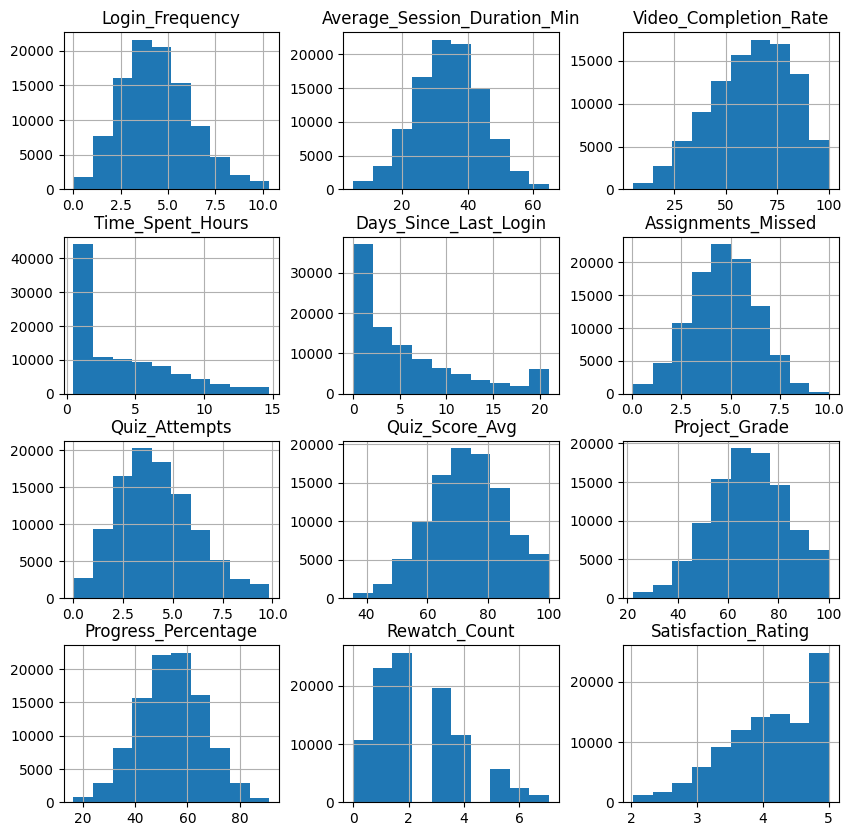


A Heatmap of the given dataset is given below..



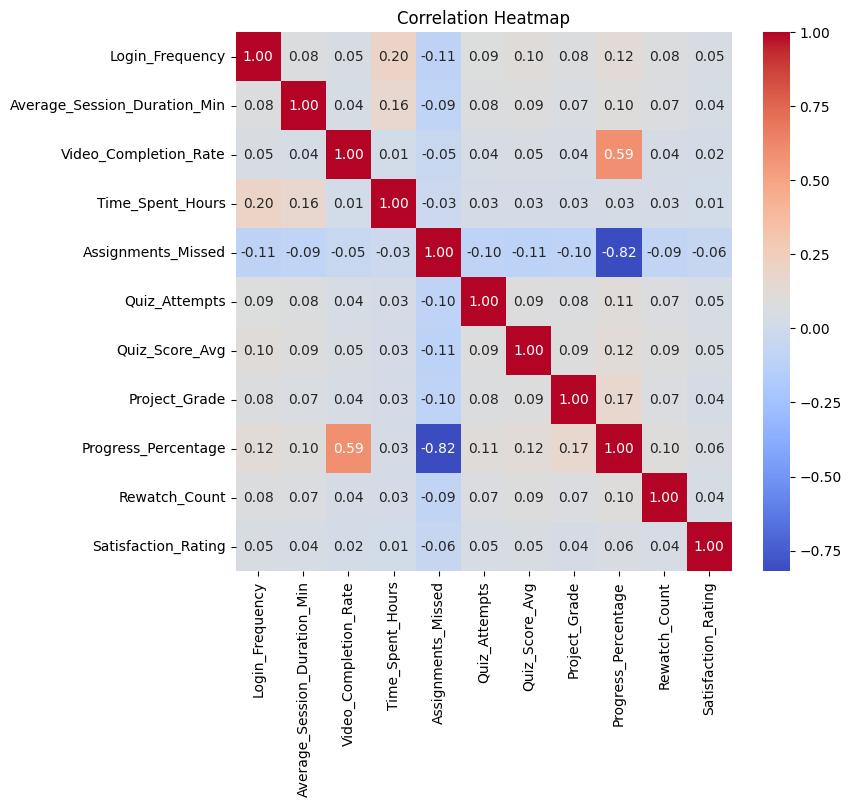

In [ ]:
#Main_module

file_name = DataIngestion.file_selection()
data = DataIngestion.data_reading(file_name)
new_data = DataIngestion.memory_downcasting(data)
summary_of_data(new_data)
col_removed_data = Remove_col(new_data)
multivariate_imputed_data = multivariate_imputation(col_removed_data, strategy='knn', n_neighbors=5, max_iter=10)
clipped_data = dynamic_outlier_clipping(multivariate_imputed_data)
duplicate_removed_data = remove_duplicates(clipped_data)
visual_Module(duplicate_removed_data)